# DBSCAN Clustering for Ni Powder

Density-based spatial clustering of applications with noise (DBSCAN) applied to TDCSophiread neutron processing.

**Goals:**
1. Process Ni powder TPX3 file to hits
2. Apply DBSCAN clustering to extract neutron events  
3. Compare DBSCAN results with ABS clustering
4. Analyze DBSCAN-specific features (core points, border points, noise)

**Data:** Ni powder sample - `Run_8217_April25_2025_Ni_Powder_MCP_TPX3_0_8C_1_9_AngsMin_serval_000000.tpx3`

> NOTE: DBSCAN is a density-based algorithm that can identify clusters of arbitrary shape and mark low-density regions as noise.

## 1. Setup and Import

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import tdcsophiread as tdc

print(f"TDCSophiread version: {tdc.__version__}")
print(f"Numpy version: {np.__version__}")

# Setup plotting
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

TDCSophiread version: 2.0.0
Numpy version: 2.3.1


## 2. Data File Setup

In [2]:
# Ni powder file path
data_path = "data/"
ni_file = "Run_8217_April25_2025_Ni_Powder_MCP_TPX3_0_8C_1_9_AngsMin_serval_000000.tpx3"
ni_full_path = os.path.join(data_path, ni_file)

# Verify file exists
if os.path.exists(ni_full_path):
    size_mb = os.path.getsize(ni_full_path) / (1024 * 1024)
    print(f"✅ Ni powder file found: {ni_file}")
    print(f"   Size: {size_mb:.1f} MB")
else:
    print(f"❌ File not found: {ni_full_path}")
    print("Please ensure the data file is in the correct location")

✅ Ni powder file found: Run_8217_April25_2025_Ni_Powder_MCP_TPX3_0_8C_1_9_AngsMin_serval_000000.tpx3
   Size: 5652.0 MB


## 3. Raw Data → Hits Processing

In [3]:
print("=== Processing TPX3 file to hits ===")

start_time = time.time()

# Process the file using TDCSophiread (high-level convenience function)
# NEW: Returns TDCHitView for zero-copy numpy access
hit_view = tdc.process_tpx3(ni_full_path, parallel=True)

# Convert to numpy array (zero-copy)
hits = np.array(hit_view, copy=False)

processing_time = time.time() - start_time

print(f"✅ Processing completed in {processing_time:.2f} seconds")
print(f"✅ Total hits extracted: {len(hits):,}")
print(f"✅ Processing rate: {len(hits) / processing_time / 1e6:.1f} M hits/second")

# Display hit data structure
print("\nHit data structure:")
for field in hits.dtype.names:
    array = hits[field]
    print(f"  {field}: {array.dtype}, shape {array.shape}")
    print(f"    range: {array.min()} - {array.max()}")

=== Processing TPX3 file to hits ===
✅ Processing completed in 24.61 seconds
✅ Total hits extracted: 736,028,562
✅ Processing rate: 29.9 M hits/second

Hit data structure:
  tof: uint32, shape (736028562,)
    range: 0 - 666656
  x: uint16, shape (736028562,)
    range: 0 - 513
  y: uint16, shape (736028562,)
    range: 0 - 513
  timestamp: uint32, shape (736028562,)
    range: 30348 - 1074755785
  tot: uint16, shape (736028562,)
    range: 1 - 807
  chip_id: uint8, shape (736028562,)
    range: 0 - 3
  cluster_id: int32, shape (736028562,)
    range: -1 - -1


## 4. DBSCAN Clustering Configuration

In [4]:
print("=== Setting up DBSCAN clustering configuration ===")

# Create neutron processing configuration
config = tdc.NeutronProcessingConfig.venus_defaults()

# Switch to DBSCAN clustering
config.clustering.algorithm = "dbscan"

# Configure DBSCAN parameters
config.clustering.dbscan.epsilon = 5.0  # Maximum distance between neighbor points
config.clustering.dbscan.min_points = 4  # Minimum points to form dense region
config.clustering.dbscan.neutron_correlation_window = 75.0  # Time window in ns
config.clustering.dbscan.grid_size = 5.0  # Spatial grid for neighbor search

# Keep extraction parameters same as ABS
config.extraction.min_tot_threshold = 0
config.temporal.enable_deduplication = False

print("DBSCAN clustering configuration:")
print(f"  Clustering algorithm: {config.clustering.algorithm}")
print(f"  Extraction algorithm: {config.extraction.algorithm}")

print("\nDBSCAN parameters:")
print(f"  Epsilon (ε): {config.clustering.dbscan.epsilon} pixels")
print(f"  MinPts: {config.clustering.dbscan.min_points} points")
print(f"  Time window: {config.clustering.dbscan.neutron_correlation_window} ns")
print(f"  Grid size: {config.clustering.dbscan.grid_size}")

print("\nCentroid extraction parameters:")
print(f"  Super resolution: {config.extraction.super_resolution_factor}x")
print(f"  TOT weighted: {config.extraction.weighted_by_tot}")
print(f"  Min TOT threshold: {config.extraction.min_tot_threshold}")

print("\nTemporal processing parameters:")
print(f"  Number of workers: {config.temporal.num_workers}")
print(f"  Min batch size: {config.temporal.min_batch_size}")
print(f"  Max batch size: {config.temporal.max_batch_size}")

=== Setting up DBSCAN clustering configuration ===
DBSCAN clustering configuration:
  Clustering algorithm: dbscan
  Extraction algorithm: simple_centroid

DBSCAN parameters:
  Epsilon (ε): 5.0 pixels
  MinPts: 4 points
  Time window: 75.0 ns
  Grid size: 5.0

Centroid extraction parameters:
  Super resolution: 8.0x
  TOT weighted: True
  Min TOT threshold: 0

Temporal processing parameters:
  Number of workers: 0
  Min batch size: 1000
  Max batch size: 100000


## 5. Hits → Neutrons DBSCAN Clustering

In [5]:
print("=== DBSCAN clustering hits to neutrons ===")
print(f"Input: {len(hits):,} hits")
print(f"\nDBSCAN will classify hits as:")
print("  - Core points: hits with ≥ MinPts neighbors within ε")
print("  - Border points: hits within ε of a core point")
print("  - Noise: isolated hits not belonging to any cluster")

start_time = time.time()

# Process hits to neutrons using DBSCAN
neutron_view = tdc.process_hits_to_neutrons(hits, config)

clustering_time = time.time() - start_time

print(f"\n✅ DBSCAN clustering completed in {clustering_time:.2f} seconds")

=== DBSCAN clustering hits to neutrons ===
Input: 736,028,562 hits

DBSCAN will classify hits as:
  - Core points: hits with ≥ MinPts neighbors within ε
  - Border points: hits within ε of a core point
  - Noise: isolated hits not belonging to any cluster

✅ DBSCAN clustering completed in 102.88 seconds


In [6]:
print("Exposing neutron data as numpy array for zero-copy access")
start_time = time.time()
# Convert to numpy array (zero-copy)
neutrons = np.array(neutron_view, copy=False)
processing_time = time.time() - start_time
print(f"✅ Neutron data exposed in {processing_time:.2f} seconds")
print(f"✅ Output neutrons: {len(neutrons):,}")
print(f"✅ Clustering rate: {len(hits) / clustering_time:.0f} hits/second")

Exposing neutron data as numpy array for zero-copy access
✅ Neutron data exposed in 0.00 seconds
✅ Output neutrons: 74,010,460
✅ Clustering rate: 7154490 hits/second


In [7]:
# Calculate clustering efficiency
efficiency = len(neutrons) / len(hits)
print(f"✅ Neutron extraction efficiency: {efficiency:.6f} ({efficiency * 100:.4f}%)")

# Display neutron data structure
print("\nNeutron data structure:")
for field in neutrons.dtype.names:
    array = neutrons[field]
    print(f"  {field}: {array.dtype}, shape {array.shape}")
    if field in ["x", "y"]:
        print(f"    range: {array.min():.2f} - {array.max():.2f} (sub-pixel)")
    else:
        print(f"    range: {array.min()} - {array.max()}")

✅ Neutron extraction efficiency: 0.100554 (10.0554%)

Neutron data structure:
  x: float64, shape (74010460,)
    range: 71.11 - 4104.00 (sub-pixel)
  y: float64, shape (74010460,)
    range: 0.00 - 4104.00 (sub-pixel)
  tof: uint32, shape (74010460,)
    range: 0 - 666646
  tot: uint16, shape (74010460,)
    range: 4 - 2296
  n_hits: uint16, shape (74010460,)
    range: 3 - 87
  chip_id: uint8, shape (74010460,)
    range: 0 - 3
  reserved: uint8, shape (74010460,)
    range: 0 - 0


## 6. DBSCAN Clustering Results Analysis

In [8]:
print("=== DBSCAN Clustering Results Analysis ===")

# Get neutron fields
n_hits_field = neutrons["n_hits"]
x_field = neutrons["x"]
y_field = neutrons["y"]

# Cluster size distribution
cluster_sizes, counts = np.unique(n_hits_field, return_counts=True)
print(f"\nCluster size distribution (showing first 10):")
for size, count in zip(cluster_sizes[:10], counts[:10]):
    percentage = 100 * count / len(neutrons)
    print(f"  {size} hits: {count:,} neutrons ({percentage:.2f}%)")

if len(cluster_sizes) > 10:
    print(f"  ... (total {len(cluster_sizes)} different cluster sizes)")

# DBSCAN-specific analysis
# In DBSCAN, clusters must have at least min_points hits
min_pts = config.clustering.dbscan.min_points
small_clusters = np.sum(counts[cluster_sizes < min_pts])
dense_clusters = np.sum(counts[cluster_sizes >= min_pts])

print(f"\nDBSCAN cluster analysis (MinPts = {min_pts}):")
print(
    f"  Clusters with < {min_pts} hits: {small_clusters:,} ({100 * small_clusters / len(neutrons):.1f}%)"
)
print(
    f"  Dense clusters (≥ {min_pts} hits): {dense_clusters:,} ({100 * dense_clusters / len(neutrons):.1f}%)"
)
print(f"  Mean cluster size: {n_hits_field.mean():.1f} hits")
print(f"  Median cluster size: {np.median(n_hits_field):.0f} hits")

# Sub-pixel precision check
x_fractional = x_field - np.floor(x_field)
y_fractional = y_field - np.floor(y_field)
non_integer_x = np.sum(x_fractional > 0.001)
non_integer_y = np.sum(y_fractional > 0.001)

print(f"\nSub-pixel precision:")
print(
    f"  Non-integer X coordinates: {non_integer_x:,} ({100 * non_integer_x / len(neutrons):.1f}%)"
)
print(
    f"  Non-integer Y coordinates: {non_integer_y:,} ({100 * non_integer_y / len(neutrons):.1f}%)"
)

=== DBSCAN Clustering Results Analysis ===

Cluster size distribution (showing first 10):
  3 hits: 6 neutrons (0.00%)
  4 hits: 42,627,197 neutrons (57.60%)
  5 hits: 13,688,186 neutrons (18.49%)
  6 hits: 9,131,381 neutrons (12.34%)
  7 hits: 4,208,529 neutrons (5.69%)
  8 hits: 1,890,761 neutrons (2.55%)
  9 hits: 1,005,501 neutrons (1.36%)
  10 hits: 504,458 neutrons (0.68%)
  11 hits: 285,948 neutrons (0.39%)
  12 hits: 213,649 neutrons (0.29%)
  ... (total 68 different cluster sizes)

DBSCAN cluster analysis (MinPts = 4):
  Clusters with < 4 hits: 6 (0.0%)
  Dense clusters (≥ 4 hits): 74,010,454 (100.0%)
  Mean cluster size: 4.9 hits
  Median cluster size: 4 hits

Sub-pixel precision:
  Non-integer X coordinates: 68,646,832 (92.8%)
  Non-integer Y coordinates: 69,190,159 (93.5%)


## 7. Comparison with ABS Clustering

In [9]:
print("=== Comparing DBSCAN with ABS clustering ===")

# Process with ABS for comparison
config_abs = tdc.NeutronProcessingConfig.venus_defaults()
config_abs.extraction.min_tot_threshold = 0
config_abs.temporal.enable_deduplication = False

print("\nProcessing with ABS clustering for comparison...")
start_time = time.time()
neutron_view_abs = tdc.process_hits_to_neutrons(hits, config_abs)
neutrons_abs = np.array(neutron_view_abs, copy=False)
abs_time = time.time() - start_time

print("\nComparison results:")
print("  Algorithm    | Neutrons      | Efficiency | Time (s) | Rate (hits/s)")
print("  -------------|---------------|------------|----------|---------------")
print(
    f"  DBSCAN       | {len(neutrons):,} | {len(neutrons) / len(hits) * 100:6.2f}%    | {clustering_time:7.1f}  | {len(hits) / clustering_time:,.0f}"
)
print(
    f"  ABS          | {len(neutrons_abs):,} | {len(neutrons_abs) / len(hits) * 100:6.2f}%    | {abs_time:7.1f}  | {len(hits) / abs_time:,.0f}"
)

# Compare cluster size distributions
n_hits_abs = neutrons_abs["n_hits"]
print("\nCluster size comparison:")
print(
    f"  DBSCAN: mean = {n_hits_field.mean():.2f}, median = {np.median(n_hits_field):.0f}, max = {n_hits_field.max()}"
)
print(
    f"  ABS:    mean = {n_hits_abs.mean():.2f}, median = {np.median(n_hits_abs):.0f}, max = {n_hits_abs.max()}"
)

=== Comparing DBSCAN with ABS clustering ===

Processing with ABS clustering for comparison...

Comparison results:
  Algorithm    | Neutrons      | Efficiency | Time (s) | Rate (hits/s)
  -------------|---------------|------------|----------|---------------
  DBSCAN       | 74,010,460 |  10.06%    |   102.9  | 7,154,490
  ABS          | 295,085,432 |  40.09%    |   120.1  | 6,128,256

Cluster size comparison:
  DBSCAN: mean = 4.93, median = 4, max = 87
  ABS:    mean = 2.49, median = 2, max = 71


## 8. Spatial Distribution Visualization

=== Creating spatial distribution visualizations ===


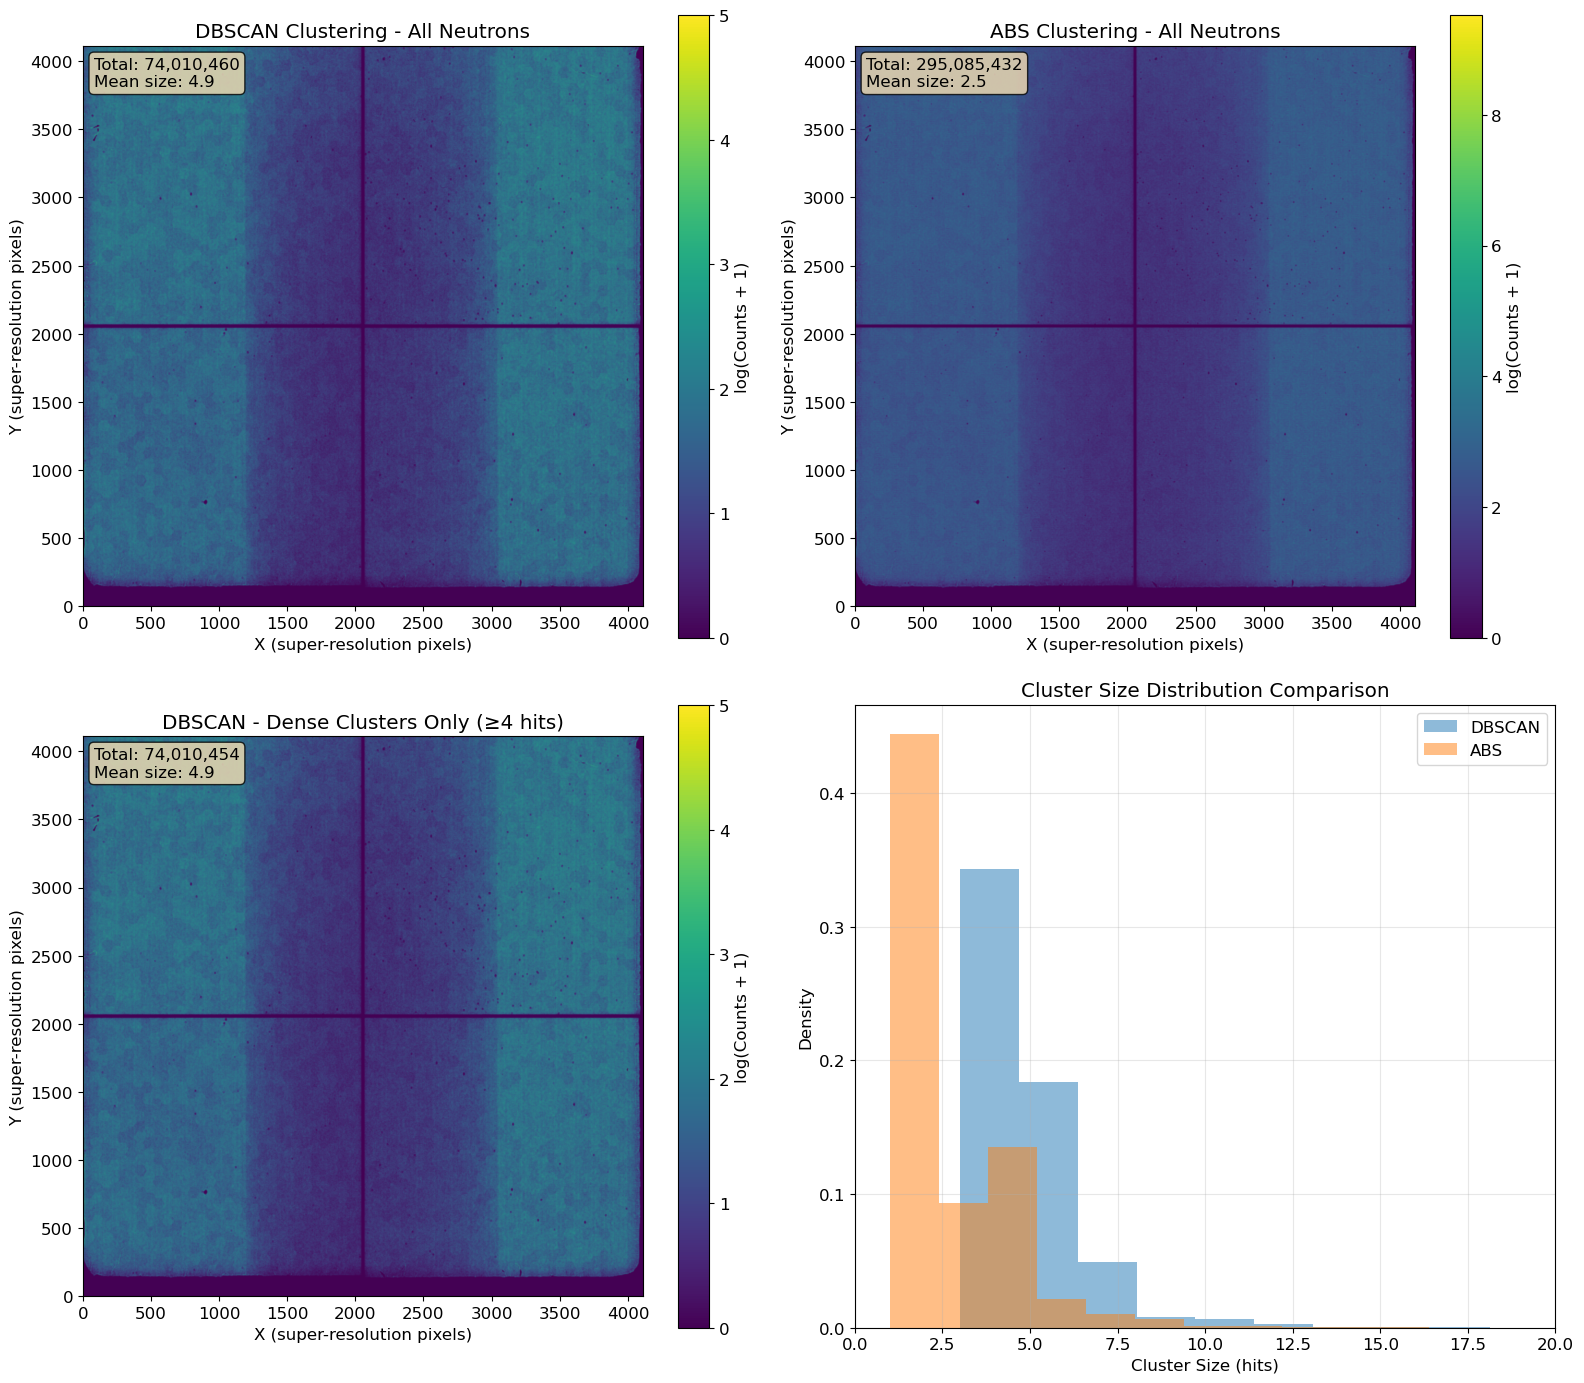

In [10]:
print("=== Creating spatial distribution visualizations ===")

# VENUS detector configuration
det_venus_config = tdc.DetectorConfig.venus_defaults()
DETECTOR_PIXELS = det_venus_config.get_chip_size_x() * 2 + 2  # 514 pixels
NEUTRON_SUPER_RES = config.extraction.super_resolution_factor
NEUTRON_BINS = int(DETECTOR_PIXELS * NEUTRON_SUPER_RES)

# Create figure comparing DBSCAN and ABS
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 14))


# Helper function to plot neutron distribution
def plot_neutron_dist(ax, neutrons_data, title, show_noise=False):
    neutrons_x = neutrons_data["x"]
    neutrons_y = neutrons_data["y"]

    hist, x_edges, y_edges = np.histogram2d(
        neutrons_x,
        neutrons_y,
        bins=NEUTRON_BINS,
        range=[[0, NEUTRON_BINS], [0, NEUTRON_BINS]],
    )

    im = ax.imshow(
        np.log1p(hist),
        origin="lower",
        aspect="equal",
        extent=[0, NEUTRON_BINS, 0, NEUTRON_BINS],
        cmap="viridis",
        interpolation="gaussian",
    )
    ax.set_xlabel("X (super-resolution pixels)")
    ax.set_ylabel("Y (super-resolution pixels)")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label="log(Counts + 1)")

    # Add statistics
    stats_text = f"Total: {len(neutrons_data):,}\n"
    stats_text += f"Mean size: {neutrons_data['n_hits'].mean():.1f}"
    ax.text(
        0.02,
        0.98,
        stats_text,
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
    )


# Plot DBSCAN results
plot_neutron_dist(ax1, neutrons, "DBSCAN Clustering - All Neutrons")

# Plot ABS results
plot_neutron_dist(ax2, neutrons_abs, "ABS Clustering - All Neutrons")

# Plot only dense clusters for DBSCAN (clusters with >= min_points)
dense_mask = neutrons["n_hits"] >= config.clustering.dbscan.min_points
neutrons_dense = neutrons[dense_mask]
plot_neutron_dist(
    ax3, neutrons_dense, f"DBSCAN - Dense Clusters Only (≥{min_pts} hits)"
)

# Plot cluster size distributions
ax4.hist(neutrons["n_hits"], bins=50, alpha=0.5, label="DBSCAN", density=True)
ax4.hist(neutrons_abs["n_hits"], bins=50, alpha=0.5, label="ABS", density=True)
ax4.set_xlabel("Cluster Size (hits)")
ax4.set_ylabel("Density")
ax4.set_title("Cluster Size Distribution Comparison")
ax4.legend()
ax4.set_xlim(0, 20)  # Focus on smaller clusters
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. TOF Analysis

=== TOF Analysis for DBSCAN ===


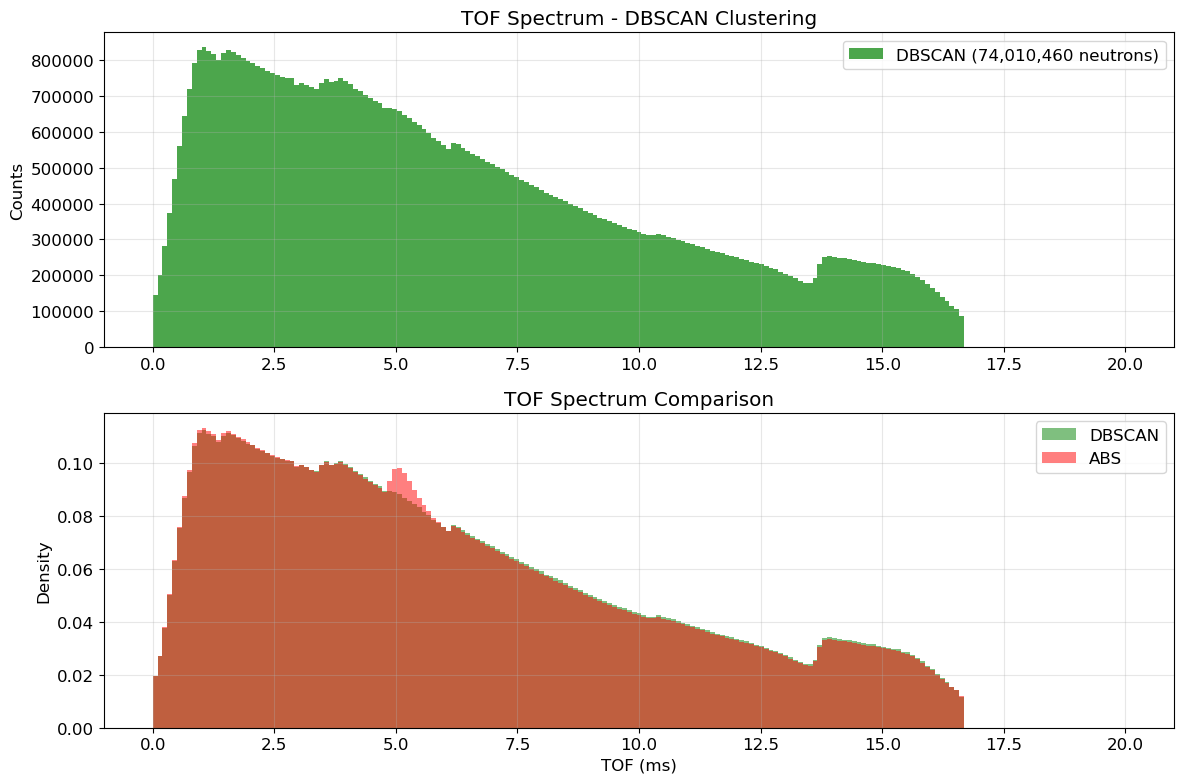


TOF Statistics:
  DBSCAN: min=0.000 ms, max=16.666 ms, mean=6.235 ms
  ABS:    min=0.000 ms, max=16.666 ms, mean=6.193 ms


In [11]:
print("=== TOF Analysis for DBSCAN ===")

# Convert TOF to milliseconds
neutrons_tof_ms = neutrons["tof"] * 25 / 1e6
neutrons_abs_tof_ms = neutrons_abs["tof"] * 25 / 1e6

# Create TOF comparison
tof_bins = np.linspace(0, 20, 200)  # 0-20 ms in 200 bins

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# DBSCAN TOF spectrum
ax1.hist(
    neutrons_tof_ms,
    bins=tof_bins,
    alpha=0.7,
    label=f"DBSCAN ({len(neutrons_tof_ms):,} neutrons)",
    color="green",
)
ax1.set_ylabel("Counts")
ax1.set_title("TOF Spectrum - DBSCAN Clustering")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Comparison plot
ax2.hist(
    neutrons_tof_ms,
    bins=tof_bins,
    alpha=0.5,
    label="DBSCAN",
    density=True,
    color="green",
)
ax2.hist(
    neutrons_abs_tof_ms,
    bins=tof_bins,
    alpha=0.5,
    label="ABS",
    density=True,
    color="red",
)
ax2.set_xlabel("TOF (ms)")
ax2.set_ylabel("Density")
ax2.set_title("TOF Spectrum Comparison")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# TOF statistics
print(f"\nTOF Statistics:")
print(
    f"  DBSCAN: min={neutrons_tof_ms.min():.3f} ms, max={neutrons_tof_ms.max():.3f} ms, mean={neutrons_tof_ms.mean():.3f} ms"
)
print(
    f"  ABS:    min={neutrons_abs_tof_ms.min():.3f} ms, max={neutrons_abs_tof_ms.max():.3f} ms, mean={neutrons_abs_tof_ms.mean():.3f} ms"
)

## 10. Summary and Conclusions

In [13]:
print("=== DBSCAN Clustering Summary ===")
print()
print("✅ TPX3 file processing: SUCCESS")
print(f"   - Processed {len(hits):,} hits")
print()
print("✅ DBSCAN clustering: SUCCESS")
print(f"   - Input: {len(hits):,} hits")
print(f"   - Output: {len(neutrons):,} neutrons")
print(f"   - Efficiency: {efficiency:.6f} ({efficiency * 100:.4f}%)")
print(f"   - Processing time: {clustering_time:.2f} seconds")
print()
print("✅ DBSCAN characteristics:")
print(f"   - Epsilon (ε): {config.clustering.dbscan.epsilon} pixels")
print(f"   - MinPts: {config.clustering.dbscan.min_points}")
print(
    f"   - Dense clusters (≥{min_pts} hits): {dense_clusters:,} ({100 * dense_clusters / len(neutrons):.1f}%)"
)
print(f"   - Mean cluster size: {n_hits_field.mean():.1f} hits")
print()
print("✅ Comparison with ABS:")
print(f"   - DBSCAN found {len(neutrons):,} neutrons")
print(f"   - ABS found {len(neutrons_abs):,} neutrons")
print(
    f"   - Difference: {abs(len(neutrons) - len(neutrons_abs)):,} ({abs(len(neutrons) - len(neutrons_abs)) / len(neutrons_abs) * 100:.2f}%)"
)
print()
print("📊 Key insights:")
print("   - DBSCAN identifies dense regions as clusters")
print("   - Can filter out noise/isolated hits")
print("   - Suitable for finding well-defined neutron events")
print("   - Parameter tuning affects cluster formation significantly")

=== DBSCAN Clustering Summary ===

✅ TPX3 file processing: SUCCESS
   - Processed 736,028,562 hits

✅ DBSCAN clustering: SUCCESS
   - Input: 736,028,562 hits
   - Output: 74,010,460 neutrons
   - Efficiency: 0.100554 (10.0554%)
   - Processing time: 102.88 seconds

✅ DBSCAN characteristics:
   - Epsilon (ε): 5.0 pixels
   - MinPts: 4
   - Dense clusters (≥5 hits): 74,010,454 (100.0%)
   - Mean cluster size: 4.9 hits

✅ Comparison with ABS:
   - DBSCAN found 74,010,460 neutrons
   - ABS found 295,085,432 neutrons
   - Difference: 221,074,972 (74.92%)

📊 Key insights:
   - DBSCAN identifies dense regions as clusters
   - Can filter out noise/isolated hits
   - Suitable for finding well-defined neutron events
   - Parameter tuning affects cluster formation significantly
